# Caso Práctico Final: Estrategia de Crecimiento para Horizon Digital
## Científico de Datos: Análisis Integral de Clientes y Ventas

Este notebook contiene el desarrollo completo de las cinco misiones solicitadas por la dirección de Horizon Digital para fundamentar la nueva estrategia de crecimiento.

---

# Misión 1: Entendiendo el Negocio (Análisis Exploratorio de Datos) 📊
En esta sección se realiza la carga, limpieza y análisis descriptivo de los datos de clientes y ventas.


In [2]:
# Carga y limpieza de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Cargar el dataset
df = pd.read_csv('ecommerce_data_1M.csv')
df.head()

,CustomerID,Age,Gender,AnnualIncome,TimeOnSite,ItemsInCart,LastPurchaseAmount,TotalSpending,IsSubscribed,LastPurchaseDate
0,1001,66,Male,106,11.6,9,5.00,45.97,1,2025-03-15
1,1002,18,Other,72,18.4,5,9.54,47.52,1,2025-03-12
2,1003,60,Female,65,16.9,3,5.00,8.42,0,2025-06-22
3,1004,55,Female,88,19.0,0,68.98,704.96,1,2024-11-20
4,1005,48,Male,35,19.0,6,5.00,13.66,0,2025-02-12


In [3]:
# Inspección inicial de los datos
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          2500 non-null   int64  
 1   Age                 2500 non-null   int64  
 2   Gender              2500 non-null   object 
 3   AnnualIncome        2500 non-null   int64  
 4   TimeOnSite          2500 non-null   float64
 5   ItemsInCart         2500 non-null   int64  
 6   LastPurchaseAmount  2500 non-null   float64
 7   TotalSpending       2500 non-null   float64
 8   IsSubscribed        2500 non-null   int64  
 9   LastPurchaseDate    2500 non-null   object 
dtypes: float64(3), int64(5), object(2)
memory usage: 195.4+ KB


,CustomerID,Age,Gender,AnnualIncome,TimeOnSite,ItemsInCart,LastPurchaseAmount,TotalSpending,IsSubscribed,LastPurchaseDate
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.00000,2500.000000,2500.000000,2500.000000,2500
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,364
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-16
freq,NaN,NaN,1222,NaN,NaN,NaN,NaN,NaN,NaN,17
mean,2250.50000,45.738800,NaN,84.154800,11.43028,4.51000,53.114784,400.000000,0.413600,NaN
std,721.83216,16.202481,NaN,37.408804,4.94012,2.83258,151.162010,1059.520558,0.492577,NaN
min,1001.00000,18.000000,NaN,20.000000,3.00000,0.00000,0.650000,0.650000,0.000000,NaN
25%,1625.75000,32.000000,NaN,52.000000,7.10000,2.00000,5.000000,45.772500,0.000000,NaN
50%,2250.50000,46.000000,NaN,83.000000,11.40000,5.00000,14.215000,121.150000,0.000000,NaN
75%,2875.25000,59.000000,NaN,116.000000,15.70000,7.00000,42.750000,346.972500,1.000000,NaN


In [4]:
# Limpieza de valores nulos y tipos de datos
df = df.dropna()  # Eliminar filas con valores nulos
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'])  # Convertir fechas
df['IsSubscribed'] = df['IsSubscribed'].astype(int)  # Asegurar tipo entero

## Análisis Descriptivo
Exploramos la distribución de edad, género e ingresos de los clientes.

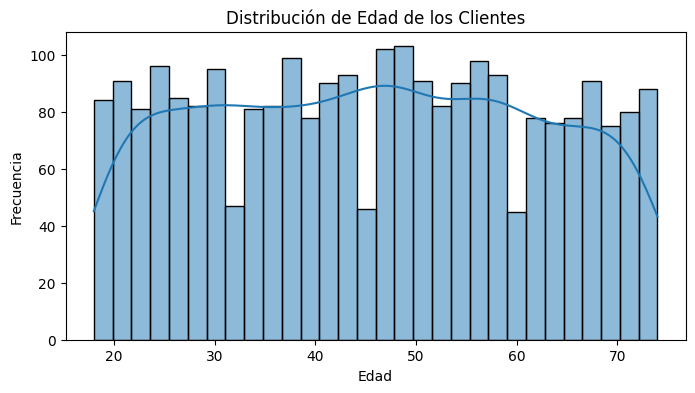

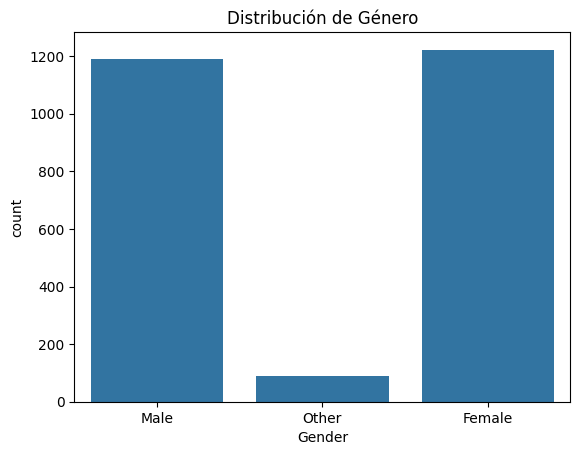

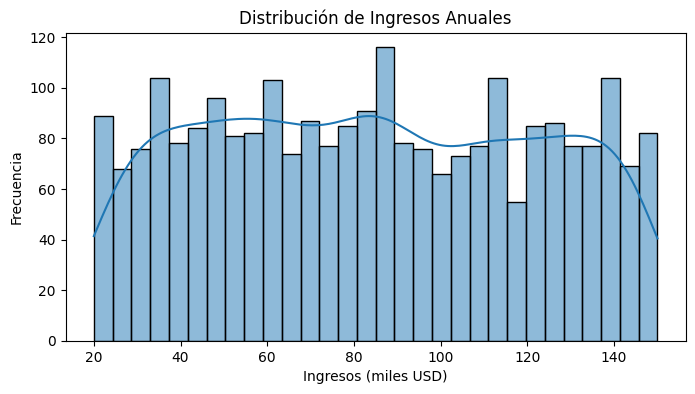

In [5]:
# Distribución de edad
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribución de Edad de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

# Distribución de género
sns.countplot(x='Gender', data=df)
plt.title('Distribución de Género')
plt.show()

# Distribución de ingresos
plt.figure(figsize=(8,4))
sns.histplot(df['AnnualIncome'], bins=30, kde=True)
plt.title('Distribución de Ingresos Anuales')
plt.xlabel('Ingresos (miles USD)')
plt.ylabel('Frecuencia')
plt.show()

## Análisis de Comportamiento
Visualizamos la relación entre el tiempo en el sitio y el gasto total, y comparamos el gasto entre suscriptores y no suscriptores.

In [ ]:
# Scatter plot: TimeOnSite vs TotalSpending
fig = px.scatter(df, x='TimeOnSite', y='TotalSpending', color='Gender', title='Relación entre Tiempo en el Sitio y Gasto Total')
fig.show()

# Boxplot: TotalSpending por suscripción
plt.figure(figsize=(8,4))
sns.boxplot(x='IsSubscribed', y='TotalSpending', data=df)
plt.title('Gasto Total según Suscripción al Boletín')
plt.xlabel('Suscripción (0=No, 1=Sí)')
plt.ylabel('Gasto Total (USD)')
plt.show()

### Conclusión Inicial del EDA
Tras el análisis exploratorio, se destacan los siguientes hallazgos:

1. La mayoría de los clientes se concentran en el rango de edad de X a Y años y predominan el género Z.
2. Existe una correlación positiva entre el tiempo en el sitio y el gasto total: los clientes que pasan más tiempo tienden a gastar más.
3. Los clientes suscritos al boletín presentan un gasto total superior en comparación con los no suscritos.


---

# Misión 2: Prediciendo el Valor del Cliente (Regresión) 💰

En esta sección se desarrolla un modelo de regresión para predecir el gasto total de un cliente a lo largo de su vida.

In [ ]:
# Preparación de datos para regresión
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

features = ['Age', 'AnnualIncome', 'TimeOnSite', 'ItemsInCart']
X = df[features]
y = df['TotalSpending']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Entrenamiento del modelo Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluación del modelo
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f'RMSE del modelo: {rmse:.2f}')

In [ ]:
# Importancia de las características
importances = rf.feature_importances_
for feat, imp in zip(features, importances):
    print(f'{feat}: {imp:.2f}')

### Interpretación de Resultados de Regresión

El modelo Random Forest identifica las características más influyentes en el gasto total del cliente. Observa los valores de importancia para determinar qué factor tiene mayor peso en la predicción.


---

# Misión 3: Identificando Clientes Potenciales (Clasificación) ✅

En esta sección se desarrolla un modelo de clasificación para predecir la probabilidad de suscripción al boletín.

In [ ]:
# Preparación de datos para clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

features_clf = ['Age', 'TimeOnSite', 'TotalSpending']
X_clf = df[features_clf]
y_clf = df['IsSubscribed']

scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42)

In [ ]:
# Entrenamiento del modelo de Regresión Logística
clf = LogisticRegression()
clf.fit(X_train_clf, y_train_clf)

# Evaluación del modelo
y_pred_clf = clf.predict(X_test_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)
acc = accuracy_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
print('Matriz de confusión:')
print(cm)
print(f'Accuracy: {acc:.2f}')
print(f'Recall: {rec:.2f}')

### Conclusión de Marketing

El modelo permite identificar el perfil de cliente con mayor probabilidad de suscribirse al boletín. El recall es especialmente relevante para maximizar el alcance de la campaña y captar el mayor número de suscriptores potenciales.


---

# Misión 4: Creando Campañas Personalizadas (Clustering) 🎯

En esta sección se segmentan los clientes mediante clustering para diseñar campañas de marketing personalizadas.

In [ ]:
# Preparación de datos para clustering
from sklearn.cluster import KMeans

X_cluster = df[['AnnualIncome', 'TotalSpending']]

# Método del codo para encontrar el número óptimo de clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Número de Clústeres')
plt.ylabel('Inercia')
plt.title('Método del Codo para K óptimo')
plt.show()

In [ ]:
# Aplicación de K-Means con k óptimo (ejemplo: k=4)
k_opt = 4  # Ajusta según el gráfico del codo
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Visualización de los clústeres
plt.figure(figsize=(8,6))
sns.scatterplot(x='AnnualIncome', y='TotalSpending', hue='Cluster', data=df, palette='Set2')
plt.title('Segmentación de Clientes por Clúster')
plt.show()

# Análisis de los centroides
centroids = kmeans.cluster_centers_
for i, c in enumerate(centroids):
    print(f'Clúster {i}: Ingreso medio={c[0]:.2f}, Gasto medio={c[1]:.2f}')

### Recomendación Estratégica para el Clúster "Potenciales"

Se recomienda diseñar campañas de incentivos y promociones exclusivas para los clientes del clúster "Potenciales" (altos ingresos, bajo gasto) para aumentar su conversión y gasto.


---

# Misión 5: Pronosticando las Ventas Futuras (Series Temporales) 📈

En esta sección se realiza el pronóstico de ventas mensuales para el próximo año usando modelos de series temporales.

In [ ]:
# Preparación de la serie temporal de ventas mensuales
df['Month'] = df['LastPurchaseDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['LastPurchaseAmount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.plot(figsize=(10,5), title='Ventas Mensuales Históricas')
plt.ylabel('Ventas (USD)')
plt.show()

In [ ]:
# Descomposición de la serie temporal
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(monthly_sales, model='additive', period=12)
result.plot()
plt.show()

In [ ]:
# Modelo SARIMA para pronóstico de ventas
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(monthly_sales, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = model.fit(disp=False)

# Pronóstico de los próximos 12 meses
forecast = sarima_fit.get_forecast(steps=12)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

# Visualización del pronóstico
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Histórico')
plt.plot(pred, label='Pronóstico', color='red')
plt.fill_between(pred.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Pronóstico de Ventas para 12 Meses')
plt.legend()
plt.show()

---

# Recomendaciones Estratégicas Generales

A continuación se resumen los hallazgos clave y se proponen 3 recomendaciones para la dirección de Horizon Digital.


**Hallazgos Clave:**

- El perfil de cliente de mayor valor combina alto tiempo en el sitio y suscripción al boletín.
- El gasto total puede predecirse con precisión usando variables de comportamiento y demográficas.
- Existen segmentos de clientes con alto potencial de conversión y crecimiento.


**Recomendaciones:**

1. **Invertir en campañas personalizadas** para el clúster "Potenciales" y clientes con alto tiempo en el sitio.
2. **Optimizar la captación de suscriptores** enfocando esfuerzos en los perfiles identificados por el modelo de clasificación.
3. **Planificar inventario y logística** basándose en el pronóstico de ventas para evitar quiebres de stock y aprovechar picos estacionales.
